In [1]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount
from boolean_analysis import find_character

fourier_learners_cache_dir = Path("fourier_learners_cache")
ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(analyzer: BooleanFourierAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["analyzer"]
        .truncate(keep_largest_n(row["terms"]))
        .prediction_score(scorer=scorer)
        for _, row in df.iterrows()
    ]


2023-01-24 19:11:58.987 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-01-24 19:11:58.992 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [LOCALE0]   2023-01-24 19:11:59.103 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
%matplotlib inline

In [3]:
analyzers: dict[tuple[int, float, str], BooleanFourierAnalyzer] = {}
for height, J2, signal_kind in product(
    [2, 3, 4],
    tqdm([0.0, 0.8, 0.3, 0.9, 0.5, 0.7, 1.0, 0.6, 0.4, 0.2, 0.1, 0.55, 0.65, 0.75, 0.85, 0.95]),
    [AmplitudeMedianBinSignalKind(), SignSignalKind()],
):
    analyzer = BooleanFourierAnalyzer(
        system=HeisenbergJ1J2(
            KagomeLattice(width=2, height=height),
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=ground_state_cache_dir,
            show_progress=False
        ),
        use_subset_symmetries=True,
        show_progress=True,
        cache_dir=fourier_learners_cache_dir,
    )
    train_set = analyzer.system.canonical_basis.states
    try:
        analyzer.fit(train_set, signal_opt=SignalOption(kind=signal_kind), from_cache_only=True)
        analyzers[height, J2, signal_kind.__class__.__name__] = analyzer
    except ValueError as e:
        print(f"Failed to load {height, J2, signal_kind.__class__.__name__} from cache")
        print(f"Error: {e}")
        break


100%|██████████| 16/16 [00:00<00:00, 132888.84it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Restoring learner from cache: fourier_learners_cache/150b040efe5aa6835a8b0b79274608ab-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-SignalOption(kind=AmplitudeMedianBinSignalKind, eigenstate=0, weights=uniform_weights).lz


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Restoring learner from cache: fourier_learners_cache/6c11e2b3640d64bf58134a6026af66a4-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


...

Finding system ground state
Restoring learner from cache: fourier_learners_cache/f216f827e7306b37b7b8f928f0a78568-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.9-True-1-SignalOption(kind=AmplitudeMedianBinSignalKind, eigenstate=0, weights=uniform_weights).lz


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Restoring learner from cache: fourier_learners_cache/047d1d16c947bc05135bf9341fe54daf-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.9-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Failed to load (4, 0.5, 'AmplitudeMedianBinSignalKind') from cache
Error: Cache not found: fourier_learners_cache/0fa3335149f81393e12a53fde8f6f8f9-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.5-True-1-SignalOption(kind=AmplitudeMedianBinSignalKind, eigenstate=0, weights=uniform_weights).lz


In [4]:
analyzers_df = (
    pd.Series(analyzers, name="analyzer")
    .to_frame()
    .reset_index()
    .rename(columns={"level_0": "height", "level_1": "J2", "level_2": "signal_kind"})
    .assign(
        number_spins=lambda df: df["analyzer"].apply(lambda a: a.system.number_spins),
        terms=lambda df: df["analyzer"].apply(
            lambda a: a.how_many_terms_to_achieve_score(
                scorer="accuracy",
                target_score=0.7,
                max_terms=10002,
                step={12: 1, 18: 1, 24: 10}[a.system.number_spins],
            )
        ),
    )
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["analyzer"], row["terms"]), axis=1
        )
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
        sign_overlap=lambda df: get_score_column(df, scorer="sign_overlap"),
        accuracy=lambda df: get_score_column(df, scorer="accuracy"),
    )
    .set_index(["height", "J2", "signal_kind"])
)


1 terms: 0.541
2 terms: 0.784
1 terms: 1.000
1 terms: 0.494
2 terms: 0.684
3 terms: 0.615
4 terms: 0.667
5 terms: 0.766
1 terms: 0.623
2 terms: 0.723
1 terms: 0.541
2 terms: 0.784
1 terms: 0.991
1 terms: 0.433
2 terms: 0.667
3 terms: 0.680
4 terms: 0.675
5 terms: 0.805
1 terms: 0.472
2 terms: 0.515
3 terms: 0.671
4 terms: 0.844
1 terms: 0.411
2 terms: 0.784
1 terms: 0.991
1 terms: 0.433
2 terms: 0.649
3 terms: 0.727
1 terms: 0.515
2 terms: 0.732
1 terms: 0.476
2 terms: 0.351
3 terms: 0.515
4 terms: 0.775
1 terms: 0.463
2 terms: 0.740
1 terms: 0.394
2 terms: 0.779
1 terms: 0.957
1 terms: 0.541
2 terms: 0.784
1 terms: 0.991
1 terms: 0.541
2 terms: 0.784
1 terms: 1.000
1 terms: 0.541
2 terms: 0.784
1 terms: 1.000
1 terms: 0.394
2 terms: 0.779
1 terms: 0.957
1 terms: 0.433
2 terms: 0.649
3 terms: 0.632
4 terms: 0.719
1 terms: 0.515
2 terms: 0.732
1 terms: 0.416
2 terms: 0.563
3 terms: 0.662
4 terms: 0.810
1 terms: 0.623
2 terms: 0.723
1 terms: 0.238
2 terms: 0.394
3 terms: 0.636
4 terms: 0

AttributeError: 'BooleanFourierAnalyzer' object has no attribute 'truncate'

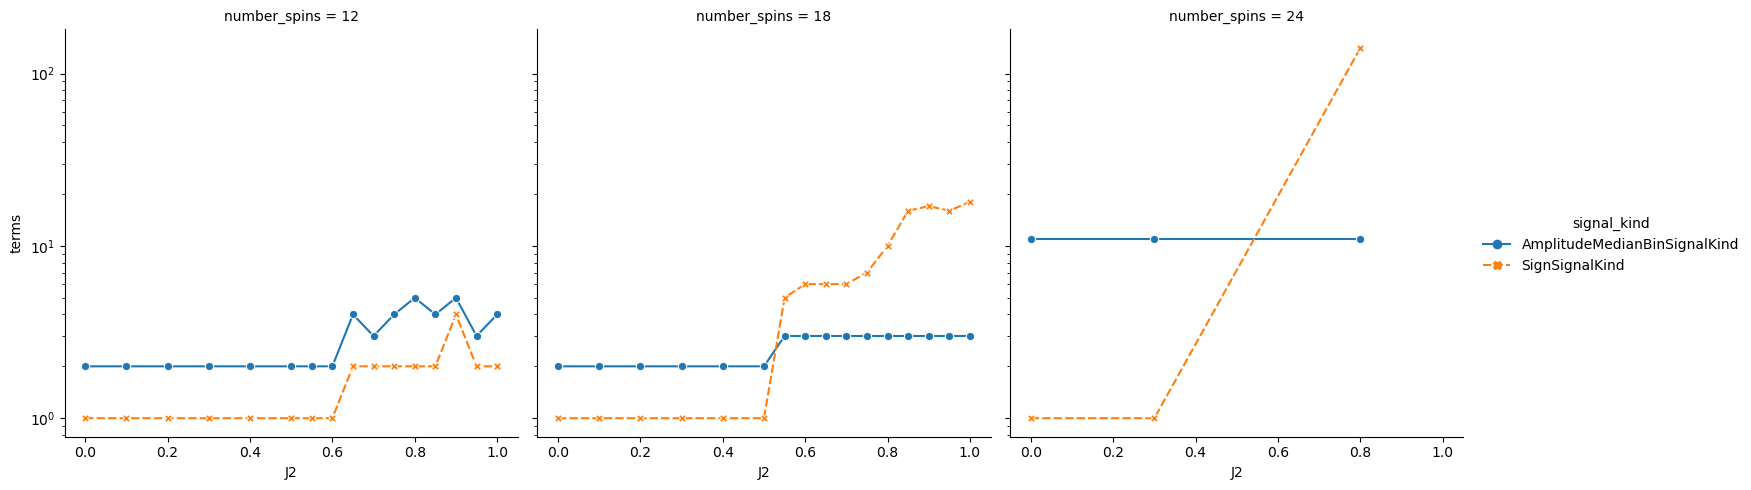

In [ ]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    markers=True,
    style="signal_kind",
).set(yscale="log")


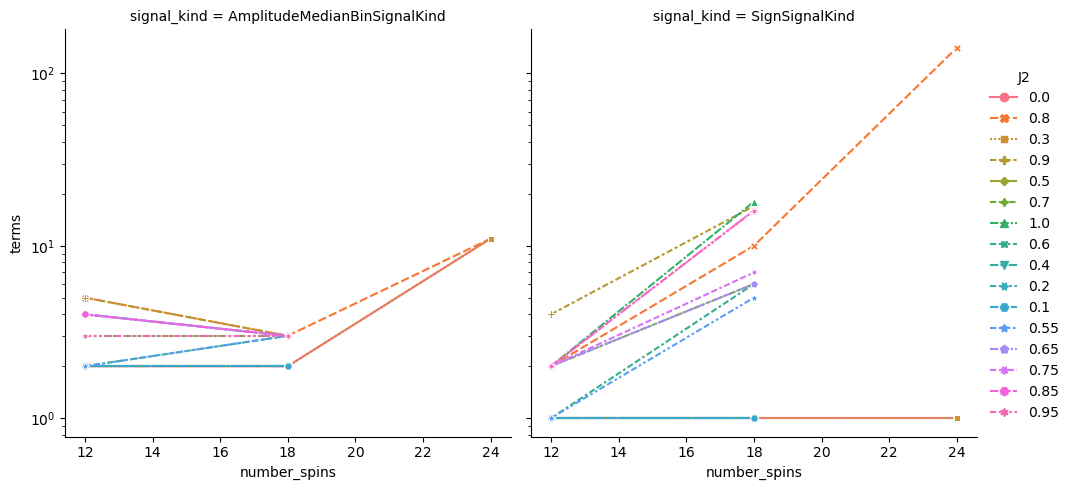

In [ ]:
sns.relplot(
    analyzers_df.reset_index(),
    #.assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
    style="J2",
).set(yscale="log")


In [ ]:
def plot_subsets(subsets, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset in zip(axes[0], subsets):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
    return fig


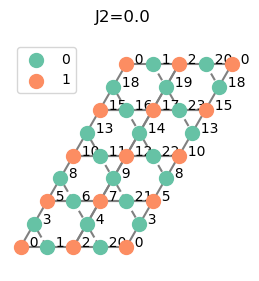

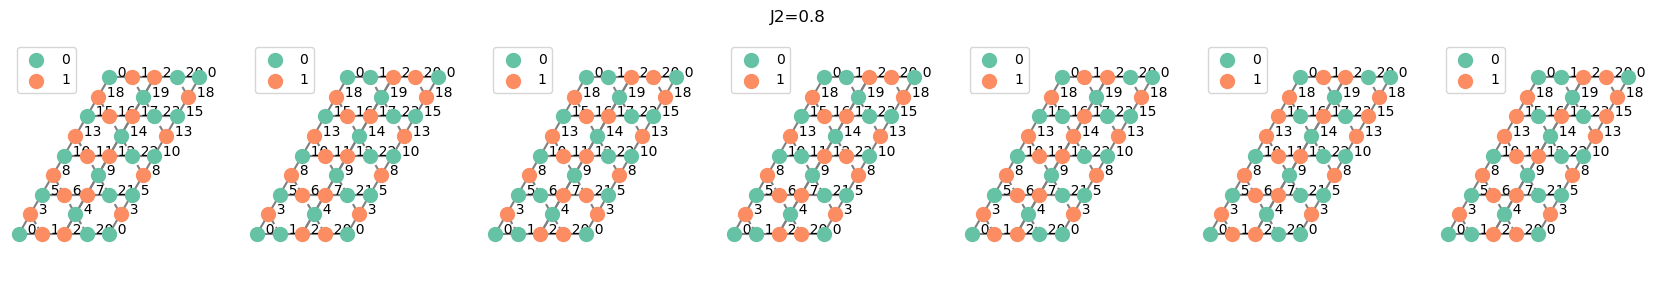

In [ ]:
height = 4
# signal = "AmplitudeMedianBinSignalKind"
signal = "SignSignalKind"
for J2, subsets in (
    analyzers_df.sort_index(level="J2")
    .xs((height, signal), level=("height", "signal_kind"))
    .assign(
        subsets=lambda df: [
            list(row["analyzer"].learner.get_coeffs_ser().iloc[: row["terms"]].index)
            for _, row in df.iterrows()
        ],
    )["subsets"]
    .items()
):
    plot_subsets(subsets[:7], KagomeLattice(width=2, height=height))
    plt.suptitle(f"J2={J2}")
    plt.show()


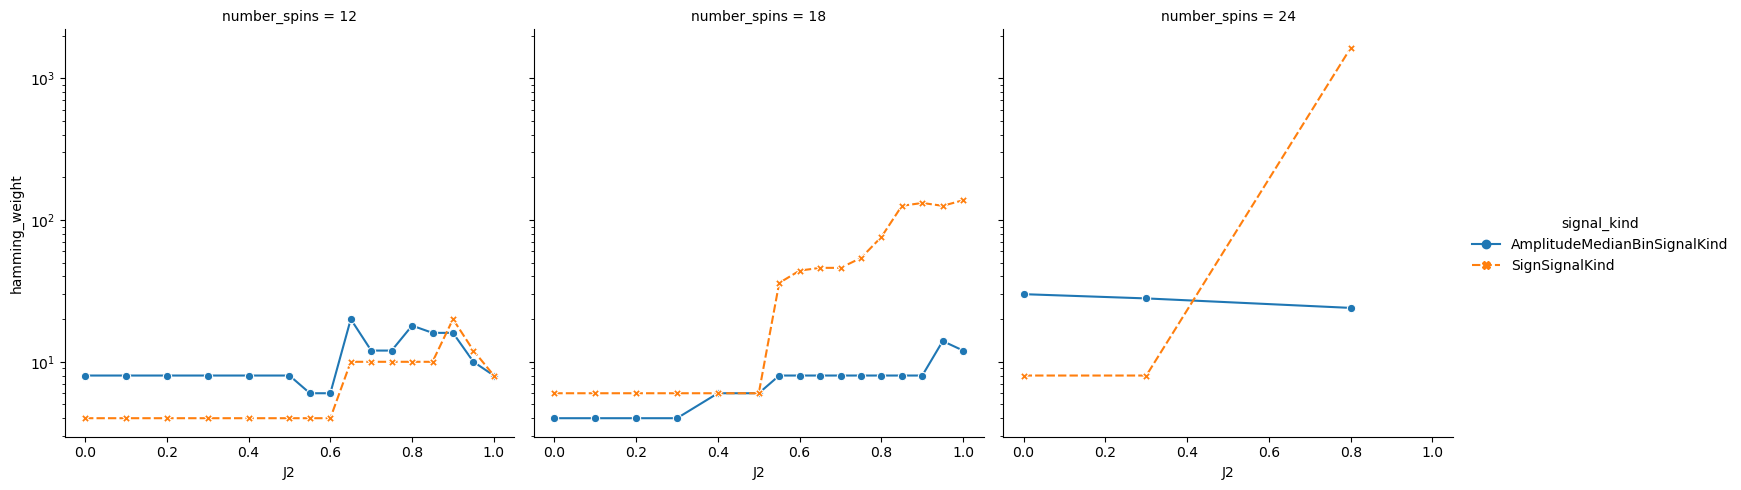

In [ ]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    markers=True,
    style="signal_kind",
    facet_kws=dict(sharex=True),
).set(yscale="log")


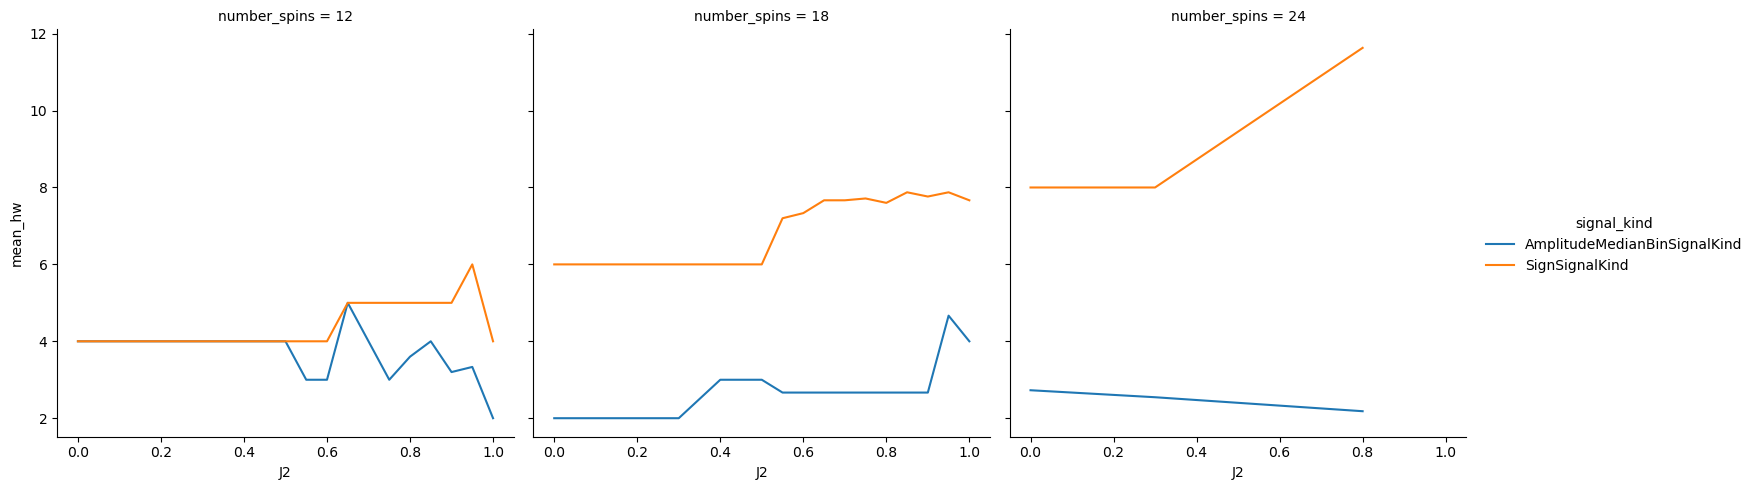

In [ ]:
sns.relplot(analyzers_df, x="J2", y="mean_hw", hue="signal_kind", col="number_spins", kind="line")

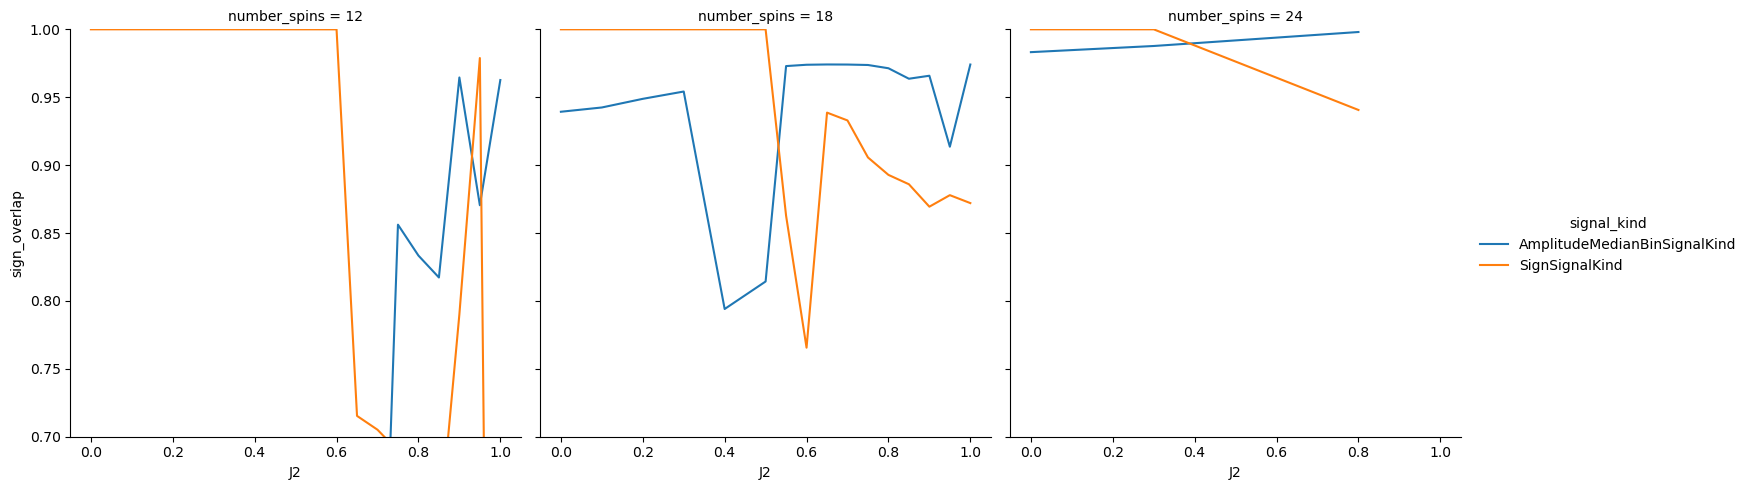

In [ ]:
sns.relplot(
    analyzers_df, x="J2", y="sign_overlap", hue="signal_kind", col="number_spins", kind="line"
).set(ylim=(0.7, 1.0))


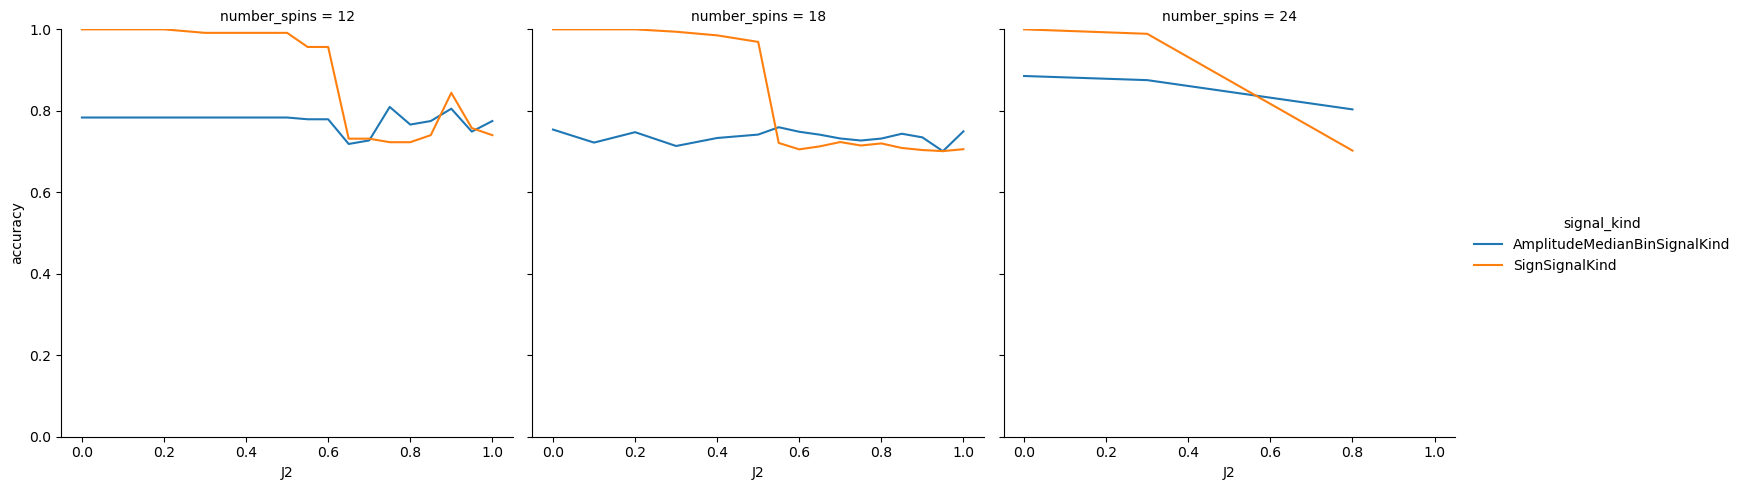

In [ ]:
sns.relplot(
    analyzers_df, x="J2", y="accuracy", hue="signal_kind", col="number_spins", kind="line"
).set(ylim=(0, 1.0))


In [ ]:
complexity_ratio_df = analyzers_df.unstack(level="signal_kind")["hamming_weight"].assign(
    ratio=lambda df:  df["SignSignalKind"] / df["AmplitudeMedianBinSignalKind"]
).reset_index()

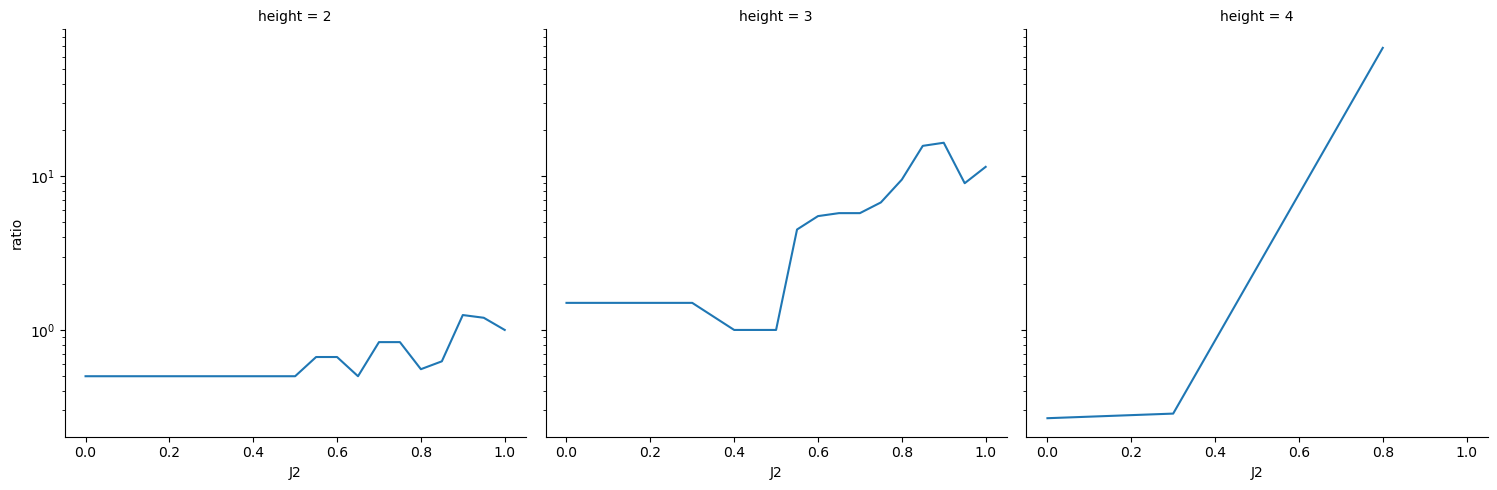

In [ ]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="height", kind="line").set(yscale="log")

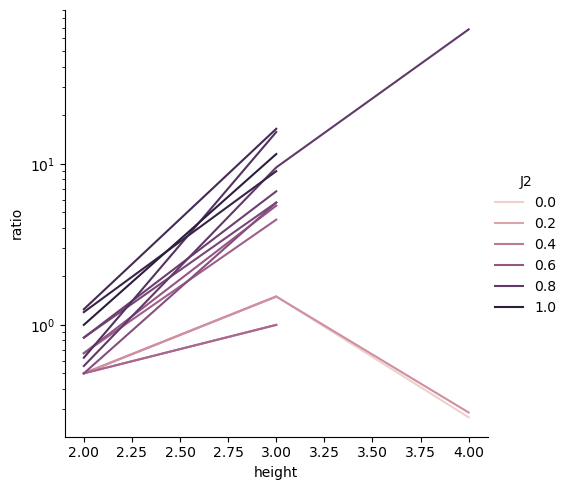

In [ ]:
sns.relplot(
    complexity_ratio_df,
    x="height",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
